In [4]:
from lasr_labs_2025_control_project.utils.setting import AppsSetting

In [7]:
apps_setting_train = AppsSetting(
    dataset_name="simple",
    cache_python_code=False,
    num_tests_to_run=10,
    dataset_type="filtered",
    split="train",
    shuffle=False,
)

In [8]:
apps_setting_test = AppsSetting(
    dataset_name="simple",
    cache_python_code=False,
    num_tests_to_run=10,
    dataset_type="filtered",
    split="test",
    shuffle=False,
)

In [11]:
len(apps_setting_train.get_dataset())

266

In [12]:
len(apps_setting_test.get_dataset())

2529

In [13]:
# Get the filtered datasets
train_dataset = apps_setting_train.get_dataset()
test_dataset = apps_setting_test.get_dataset()

# Extract problem IDs from the filtered datasets
train_problem_ids = [sample.id for sample in train_dataset]
test_problem_ids = [sample.id for sample in test_dataset]

print(f"Train dataset: {len(train_problem_ids)} problems")
print(f"Test dataset: {len(test_problem_ids)} problems")
print(f"Total filtered: {len(train_problem_ids) + len(test_problem_ids)} problems")


Train dataset: 266 problems
Test dataset: 2529 problems
Total filtered: 2795 problems


In [14]:
# Convert to integers and sort for analysis
train_problem_ids_int = sorted([int(pid) for pid in train_problem_ids if pid is not None])
test_problem_ids_int = sorted([int(pid) for pid in test_problem_ids if pid is not None])

print("Train problem IDs (first 20):")
print(train_problem_ids_int[:20])
print(f"\nTrain problem IDs (last 20):")
print(train_problem_ids_int[-20:])

print(f"\nTest problem IDs (first 20):")
print(test_problem_ids_int[:20])
print(f"\nTest problem IDs (last 20):")
print(test_problem_ids_int[-20:])


Train problem IDs (first 20):
[16, 36, 51, 58, 112, 1603, 1604, 1605, 1606, 1607, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]

Train problem IDs (last 20):
[2281, 2282, 2284, 2308, 2310, 2311, 2313, 2314, 2316, 2318, 2320, 2321, 2322, 2352, 2353, 2354, 2374, 2589, 2637, 2646]

Test problem IDs (first 20):
[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21]

Test problem IDs (last 20):
[4469, 4472, 4477, 4478, 4506, 4507, 4508, 4510, 4512, 4516, 4520, 4521, 4522, 4524, 4531, 4628, 4631, 4638, 4641, 4647]


In [15]:
# Analyze the range and distribution of problem IDs
print("=== PROBLEM ID ANALYSIS ===")
print(f"Train dataset range: {min(train_problem_ids_int)} to {max(train_problem_ids_int)}")
print(f"Test dataset range: {min(test_problem_ids_int)} to {max(test_problem_ids_int)}")

# Check for overlaps
train_set = set(train_problem_ids_int)
test_set = set(test_problem_ids_int)
overlap = train_set.intersection(test_set)
print(f"Overlap between train and test: {len(overlap)} problems")
if overlap:
    print(f"Overlapping IDs: {sorted(list(overlap))}")

# Check if there are any gaps in the original APPS numbering
all_filtered_ids = sorted(train_problem_ids_int + test_problem_ids_int)
print(f"\nAll filtered problem IDs range: {min(all_filtered_ids)} to {max(all_filtered_ids)}")
print(f"Total unique filtered problems: {len(set(all_filtered_ids))}")


=== PROBLEM ID ANALYSIS ===
Train dataset range: 16 to 2646
Test dataset range: 0 to 4647
Overlap between train and test: 201 problems
Overlapping IDs: [16, 36, 58, 112, 1603, 1604, 1605, 1606, 1607, 2000, 2001, 2002, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2017, 2020, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2052, 2053, 2056, 2057, 2058, 2059, 2063, 2065, 2067, 2068, 2070, 2071, 2072, 2073, 2074, 2075, 2077, 2082, 2083, 2084, 2086, 2088, 2089, 2090, 2093, 2094, 2095, 2096, 2098, 2099, 2100, 2101, 2102, 2103, 2106, 2107, 2108, 2110, 2111, 2112, 2113, 2114, 2115, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124, 2125, 2126, 2128, 2130, 2131, 2132, 2133, 2134, 2135, 2137, 2138, 2139, 2140, 2143, 2146, 2147, 2149, 2152, 2153, 2154, 2155, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2165, 2166, 2167, 2172, 2173, 2174, 2175, 2176, 2178, 2179, 2180, 21

In [16]:
# Let's also check what the original APPS dataset looks like without filtering
print("\n=== COMPARISON WITH ORIGINAL APPS ===")

# Get original datasets (without filtering)
apps_setting_train_original = AppsSetting(
    dataset_name="simple",
    cache_python_code=False,
    num_tests_to_run=10,
    dataset_type="original",  # This is the key difference
    split="train",
    shuffle=False,
)

apps_setting_test_original = AppsSetting(
    dataset_name="simple",
    cache_python_code=False,
    num_tests_to_run=10,
    dataset_type="original",  # This is the key difference
    split="test",
    shuffle=False,
)

original_train_dataset = apps_setting_train_original.get_dataset()
original_test_dataset = apps_setting_test_original.get_dataset()

print(f"Original train dataset: {len(original_train_dataset)} problems")
print(f"Original test dataset: {len(original_test_dataset)} problems")
print(f"Original total: {len(original_train_dataset) + len(original_test_dataset)} problems")

# Extract original problem IDs
original_train_ids = [int(sample.id) for sample in original_train_dataset if sample.id is not None]
original_test_ids = [int(sample.id) for sample in original_test_dataset if sample.id is not None]

print(f"Original train range: {min(original_train_ids)} to {max(original_train_ids)}")
print(f"Original test range: {min(original_test_ids)} to {max(original_test_ids)}")



=== COMPARISON WITH ORIGINAL APPS ===
Original train dataset: 624 problems
Original test dataset: 3666 problems
Original total: 4290 problems
Original train range: 0 to 4757
Original test range: 0 to 4750


In [17]:
# Calculate filtering statistics
print("\n=== FILTERING STATISTICS ===")
train_filtered_count = len(train_problem_ids_int)
test_filtered_count = len(test_problem_ids_int)
original_train_count = len(original_train_ids)
original_test_count = len(original_test_ids)

print(f"Train: {train_filtered_count}/{original_train_count} problems kept ({train_filtered_count/original_train_count*100:.1f}%)")
print(f"Test: {test_filtered_count}/{original_test_count} problems kept ({test_filtered_count/original_test_count*100:.1f}%)")
print(f"Total: {train_filtered_count + test_filtered_count}/{original_train_count + original_test_count} problems kept ({(train_filtered_count + test_filtered_count)/(original_train_count + original_test_count)*100:.1f}%)")

# Show which problems were filtered out
original_train_set = set(original_train_ids)
original_test_set = set(original_test_ids)
filtered_train_set = set(train_problem_ids_int)
filtered_test_set = set(test_problem_ids_int)

train_filtered_out = original_train_set - filtered_train_set
test_filtered_out = original_test_set - filtered_test_set

print(f"\nTrain problems filtered out: {len(train_filtered_out)}")
print(f"Test problems filtered out: {len(test_filtered_out)}")
print(f"Total problems filtered out: {len(train_filtered_out) + len(test_filtered_out)}")



=== FILTERING STATISTICS ===
Train: 266/624 problems kept (42.6%)
Test: 2529/3666 problems kept (69.0%)
Total: 2795/4290 problems kept (65.2%)

Train problems filtered out: 358
Test problems filtered out: 1137
Total problems filtered out: 1495


In [18]:
# Let's examine a few examples of filtered out problems to understand why they were removed
print("\n=== EXAMINING FILTERED OUT PROBLEMS ===")

# Get a few examples of filtered out problems
sample_filtered_train = sorted(list(train_filtered_out))[:5]
sample_filtered_test = sorted(list(test_filtered_out))[:5]

print(f"Sample train problems filtered out: {sample_filtered_train}")
print(f"Sample test problems filtered out: {sample_filtered_test}")

# Let's look at one of the filtered out problems to see what's missing
if sample_filtered_train:
    sample_id = sample_filtered_train[0]
    print(f"\nExamining train problem {sample_id}:")
    
    # Get the original sample
    for sample in original_train_dataset:
        if sample.id is not None and int(sample.id) == sample_id:
            print(f"Problem ID: {sample.id}")
            print(f"Input length: {len(sample.input) if sample.input else 'None'}")
            if sample.input:
                print(f"Contains 'Input': {'Input' in sample.input}")
                print(f"Contains 'Output': {'Output' in sample.input}")
                print(f"Contains 'Examples': {'Examples' in sample.input}")
                print(f"Input preview: {sample.input[:200]}...")
            break



=== EXAMINING FILTERED OUT PROBLEMS ===
Sample train problems filtered out: [0, 1, 2, 3, 4]
Sample test problems filtered out: [6, 19, 51, 69, 91]

Examining train problem 0:
Problem ID: 0
Input length: 2599
Contains 'Input': True
Contains 'Output': True
Contains 'Examples': False
Input preview: Polycarp has $n$ different binary words. A word called binary if it contains only characters '0' and '1'. For example, these words are binary: "0001", "11", "0" and "0011100".

Polycarp wants to offer...


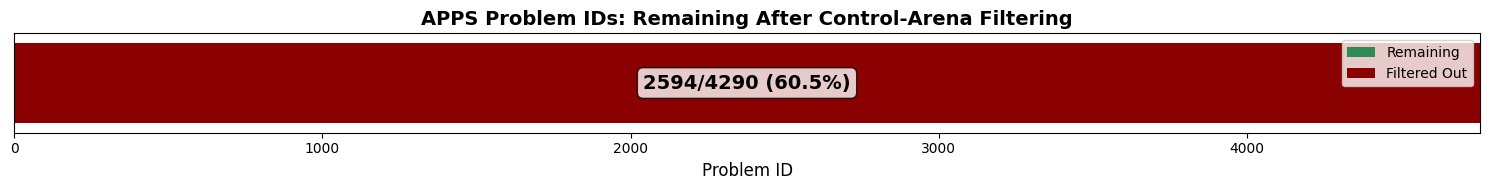

Visualization shows 2594 out of 4290 original problem IDs remain after filtering
Filtering rate: 60.5%


In [19]:
# Create a visualization of which problem IDs remain after filtering
import matplotlib.pyplot as plt
import numpy as np

# Get the full range of problem IDs from the original datasets
all_original_ids = sorted(original_train_ids + original_test_ids)
all_filtered_ids_set = set(train_problem_ids_int + test_problem_ids_int)

# Create a binary array indicating which problem IDs remain
max_id = max(all_original_ids)
remaining_mask = np.zeros(max_id + 1, dtype=bool)

for pid in all_filtered_ids_set:
    if pid <= max_id:
        remaining_mask[pid] = True

# Create the visualization
fig, ax = plt.subplots(figsize=(15, 2))

# Create the bar chart
colors = ['#2E8B57' if remaining_mask[i] else '#8B0000' for i in range(max_id + 1)]
ax.barh(0, range(max_id + 1), height=0.8, color=colors, linewidth=0)

# Add the count text in the center
total_remaining = np.sum(remaining_mask)
total_original = len(all_original_ids)
percentage = (total_remaining / total_original) * 100

ax.text(max_id // 2, 0, f'{total_remaining}/{total_original} ({percentage:.1f}%)', 
        ha='center', va='center', fontsize=14, fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Customize the plot
ax.set_xlim(0, max_id)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Problem ID', fontsize=12)
ax.set_title('APPS Problem IDs: Remaining After Control-Arena Filtering', fontsize=14, fontweight='bold')
ax.set_yticks([])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E8B57', label='Remaining'),
                   Patch(facecolor='#8B0000', label='Filtered Out')]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

print(f"Visualization shows {total_remaining} out of {total_original} original problem IDs remain after filtering")
print(f"Filtering rate: {percentage:.1f}%")


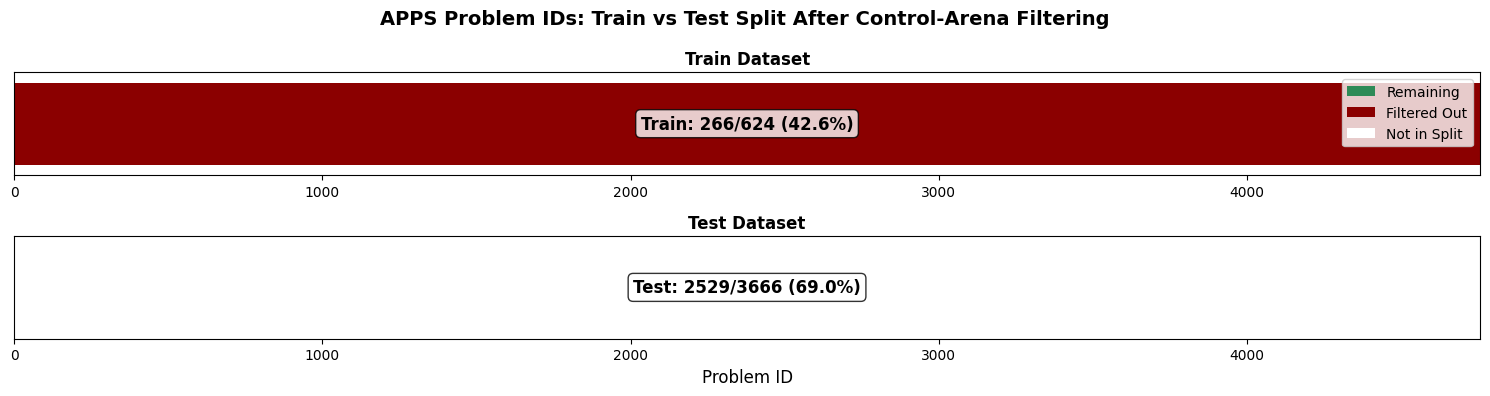

Train: 266/624 problems remain (42.6%)
Test: 2529/3666 problems remain (69.0%)
Total: 2795/4290 problems remain (65.2%)


In [20]:
# Create a more detailed visualization showing train/test split
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4))

# Train dataset visualization
train_mask = np.zeros(max_id + 1, dtype=int)  # 0: not in train, 1: filtered out, 2: remaining
for pid in original_train_ids:
    if pid in train_problem_ids_int:
        train_mask[pid] = 2  # Remaining
    else:
        train_mask[pid] = 1  # Filtered out

train_colors = ['white' if train_mask[i] == 0 else '#8B0000' if train_mask[i] == 1 else '#2E8B57' for i in range(max_id + 1)]
ax1.barh(0, range(max_id + 1), height=0.8, color=train_colors, linewidth=0)

train_remaining = len(train_problem_ids_int)
train_total = len(original_train_ids)
train_percentage = (train_remaining / train_total) * 100

ax1.text(max_id // 2, 0, f'Train: {train_remaining}/{train_total} ({train_percentage:.1f}%)', 
         ha='center', va='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.set_xlim(0, max_id)
ax1.set_ylim(-0.5, 0.5)
ax1.set_title('Train Dataset', fontsize=12, fontweight='bold')
ax1.set_yticks([])

# Test dataset visualization
test_mask = np.zeros(max_id + 1, dtype=int)  # 0: not in test, 1: filtered out, 2: remaining
for pid in original_test_ids:
    if pid in test_problem_ids_int:
        test_mask[pid] = 2  # Remaining
    else:
        test_mask[pid] = 1  # Filtered out

test_colors = ['white' if test_mask[i] == 0 else '#8B0000' if test_mask[i] == 1 else '#2E8B57' for i in range(max_id + 1)]
ax2.barh(0, range(max_id + 1), height=0.8, color=test_colors, linewidth=0)

test_remaining = len(test_problem_ids_int)
test_total = len(original_test_ids)
test_percentage = (test_remaining / test_total) * 100

ax2.text(max_id // 2, 0, f'Test: {test_remaining}/{test_total} ({test_percentage:.1f}%)', 
         ha='center', va='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax2.set_xlim(0, max_id)
ax2.set_ylim(-0.5, 0.5)
ax2.set_title('Test Dataset', fontsize=12, fontweight='bold')
ax2.set_xlabel('Problem ID', fontsize=12)
ax2.set_yticks([])

# Add legend
legend_elements = [Patch(facecolor='#2E8B57', label='Remaining'),
                   Patch(facecolor='#8B0000', label='Filtered Out'),
                   Patch(facecolor='white', label='Not in Split')]
ax1.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

plt.suptitle('APPS Problem IDs: Train vs Test Split After Control-Arena Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Train: {train_remaining}/{train_total} problems remain ({train_percentage:.1f}%)")
print(f"Test: {test_remaining}/{test_total} problems remain ({test_percentage:.1f}%)")
print(f"Total: {train_remaining + test_remaining}/{train_total + test_total} problems remain ({(train_remaining + test_remaining)/(train_total + test_total)*100:.1f}%)")


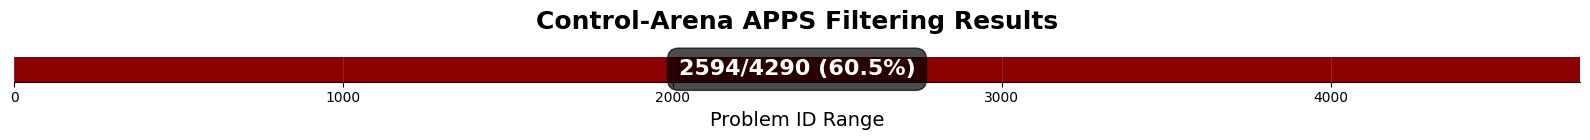

\nSummary:
• 2594 out of 4290 problem IDs remain after Control-Arena filtering
• 1696 problem IDs were filtered out
• Retention rate: 60.5%
• Problem ID range: 0 to 4757


In [21]:
# Create a simple visualization similar to the reference image
fig, ax = plt.subplots(figsize=(16, 1.5))

# Create the horizontal bar with thin vertical strips
colors = ['#2E8B57' if remaining_mask[i] else '#8B0000' for i in range(max_id + 1)]
ax.barh(0, range(max_id + 1), height=0.6, color=colors, linewidth=0)

# Add the count text in the center (similar to the reference)
ax.text(max_id // 2, 0, f'{total_remaining}/{total_original} ({percentage:.1f}%)', 
        ha='center', va='center', fontsize=16, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))

# Customize the plot to match the reference style
ax.set_xlim(0, max_id)
ax.set_ylim(-0.3, 0.3)
ax.set_title('Control-Arena APPS Filtering Results', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Problem ID Range', fontsize=14)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)

# Add subtle grid
ax.grid(True, axis='x', alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\\nSummary:")
print(f"• {total_remaining} out of {total_original} problem IDs remain after Control-Arena filtering")
print(f"• {total_original - total_remaining} problem IDs were filtered out")
print(f"• Retention rate: {percentage:.1f}%")
print(f"• Problem ID range: 0 to {max_id}")


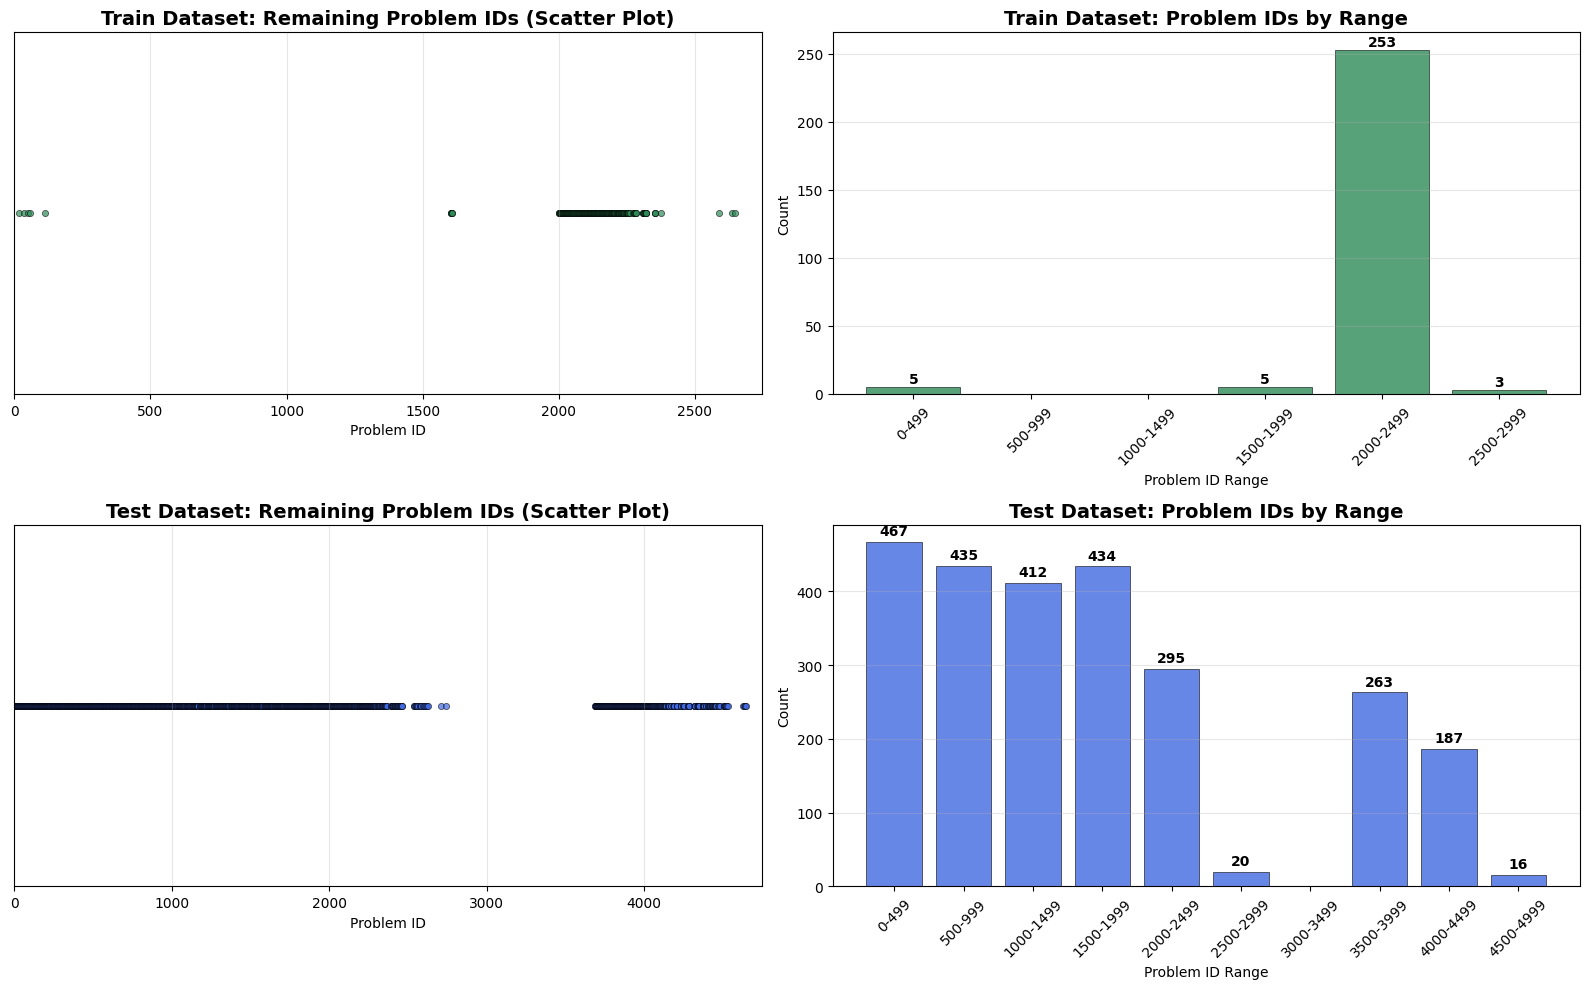

Train dataset: 266 problem IDs remain
Test dataset: 2529 problem IDs remain


In [22]:
# Create scatterplots and bar charts for train and test problem IDs
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

# Train dataset visualizations
ax1.scatter(train_problem_ids_int, [1] * len(train_problem_ids_int), 
           c='#2E8B57', s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_title('Train Dataset: Remaining Problem IDs (Scatter Plot)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Problem ID')
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(train_problem_ids_int) + 100)

# Train bar chart - show distribution by ranges
train_ranges = [(0, 500), (500, 1000), (1000, 1500), (1500, 2000), (2000, 2500), (2500, 3000)]
train_counts = []
for start, end in train_ranges:
    count = sum(1 for pid in train_problem_ids_int if start <= pid < end)
    train_counts.append(count)

range_labels = [f'{start}-{end-1}' for start, end in train_ranges]
bars1 = ax2.bar(range_labels, train_counts, color='#2E8B57', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_title('Train Dataset: Problem IDs by Range', fontsize=14, fontweight='bold')
ax2.set_xlabel('Problem ID Range')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars1, train_counts):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(count), ha='center', va='bottom', fontweight='bold')

# Test dataset visualizations
ax3.scatter(test_problem_ids_int, [1] * len(test_problem_ids_int), 
           c='#4169E1', s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
ax3.set_title('Test Dataset: Remaining Problem IDs (Scatter Plot)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Problem ID')
ax3.set_ylabel('')
ax3.set_yticks([])
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(test_problem_ids_int) + 100)

# Test bar chart - show distribution by ranges
test_ranges = [(0, 500), (500, 1000), (1000, 1500), (1500, 2000), (2000, 2500), (2500, 3000), (3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000)]
test_counts = []
for start, end in test_ranges:
    count = sum(1 for pid in test_problem_ids_int if start <= pid < end)
    test_counts.append(count)

test_range_labels = [f'{start}-{end-1}' for start, end in test_ranges]
bars2 = ax4.bar(test_range_labels, test_counts, color='#4169E1', alpha=0.8, edgecolor='black', linewidth=0.5)
ax4.set_title('Test Dataset: Problem IDs by Range', fontsize=14, fontweight='bold')
ax4.set_xlabel('Problem ID Range')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars2, test_counts):
    if count > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Train dataset: {len(train_problem_ids_int)} problem IDs remain")
print(f"Test dataset: {len(test_problem_ids_int)} problem IDs remain")


In [23]:
# Detailed analysis of the remaining problem IDs
print("=== DETAILED ANALYSIS OF REMAINING PROBLEM IDs ===")
print(f"\nTRAIN DATASET ({len(train_problem_ids_int)} problems):")
print(f"Range: {min(train_problem_ids_int)} to {max(train_problem_ids_int)}")
print(f"First 20: {train_problem_ids_int[:20]}")
print(f"Last 20: {train_problem_ids_int[-20:]}")

print(f"\nTEST DATASET ({len(test_problem_ids_int)} problems):")
print(f"Range: {min(test_problem_ids_int)} to {max(test_problem_ids_int)}")
print(f"First 20: {test_problem_ids_int[:20]}")
print(f"Last 20: {test_problem_ids_int[-20:]}")

# Show overlap between train and test
overlap_ids = sorted(list(set(train_problem_ids_int) & set(test_problem_ids_int)))
print(f"\nOVERLAP: {len(overlap_ids)} problem IDs appear in both train and test")
print(f"Overlap IDs: {overlap_ids[:20]}{'...' if len(overlap_ids) > 20 else ''}")

# Create a summary table
import pandas as pd

# Train dataset summary by ranges
train_summary = []
for start, end in train_ranges:
    count = sum(1 for pid in train_problem_ids_int if start <= pid < end)
    if count > 0:
        train_summary.append({'Range': f'{start}-{end-1}', 'Count': count, 'Dataset': 'Train'})

# Test dataset summary by ranges  
test_summary = []
for start, end in test_ranges:
    count = sum(1 for pid in test_problem_ids_int if start <= pid < end)
    if count > 0:
        test_summary.append({'Range': f'{start}-{end-1}', 'Count': count, 'Dataset': 'Test'})

# Combine and display
summary_df = pd.DataFrame(train_summary + test_summary)
print(f"\nSUMMARY BY RANGES:")
print(summary_df.to_string(index=False))


=== DETAILED ANALYSIS OF REMAINING PROBLEM IDs ===

TRAIN DATASET (266 problems):
Range: 16 to 2646
First 20: [16, 36, 51, 58, 112, 1603, 1604, 1605, 1606, 1607, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]
Last 20: [2281, 2282, 2284, 2308, 2310, 2311, 2313, 2314, 2316, 2318, 2320, 2321, 2322, 2352, 2353, 2354, 2374, 2589, 2637, 2646]

TEST DATASET (2529 problems):
Range: 0 to 4647
First 20: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21]
Last 20: [4469, 4472, 4477, 4478, 4506, 4507, 4508, 4510, 4512, 4516, 4520, 4521, 4522, 4524, 4531, 4628, 4631, 4638, 4641, 4647]

OVERLAP: 201 problem IDs appear in both train and test
Overlap IDs: [16, 36, 58, 112, 1603, 1604, 1605, 1606, 1607, 2000, 2001, 2002, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]...

SUMMARY BY RANGES:
    Range  Count Dataset
    0-499      5   Train
1500-1999      5   Train
2000-2499    253   Train
2500-2999      3   Train
    0-499    467    Test
  500-999    435    Test
1000-14

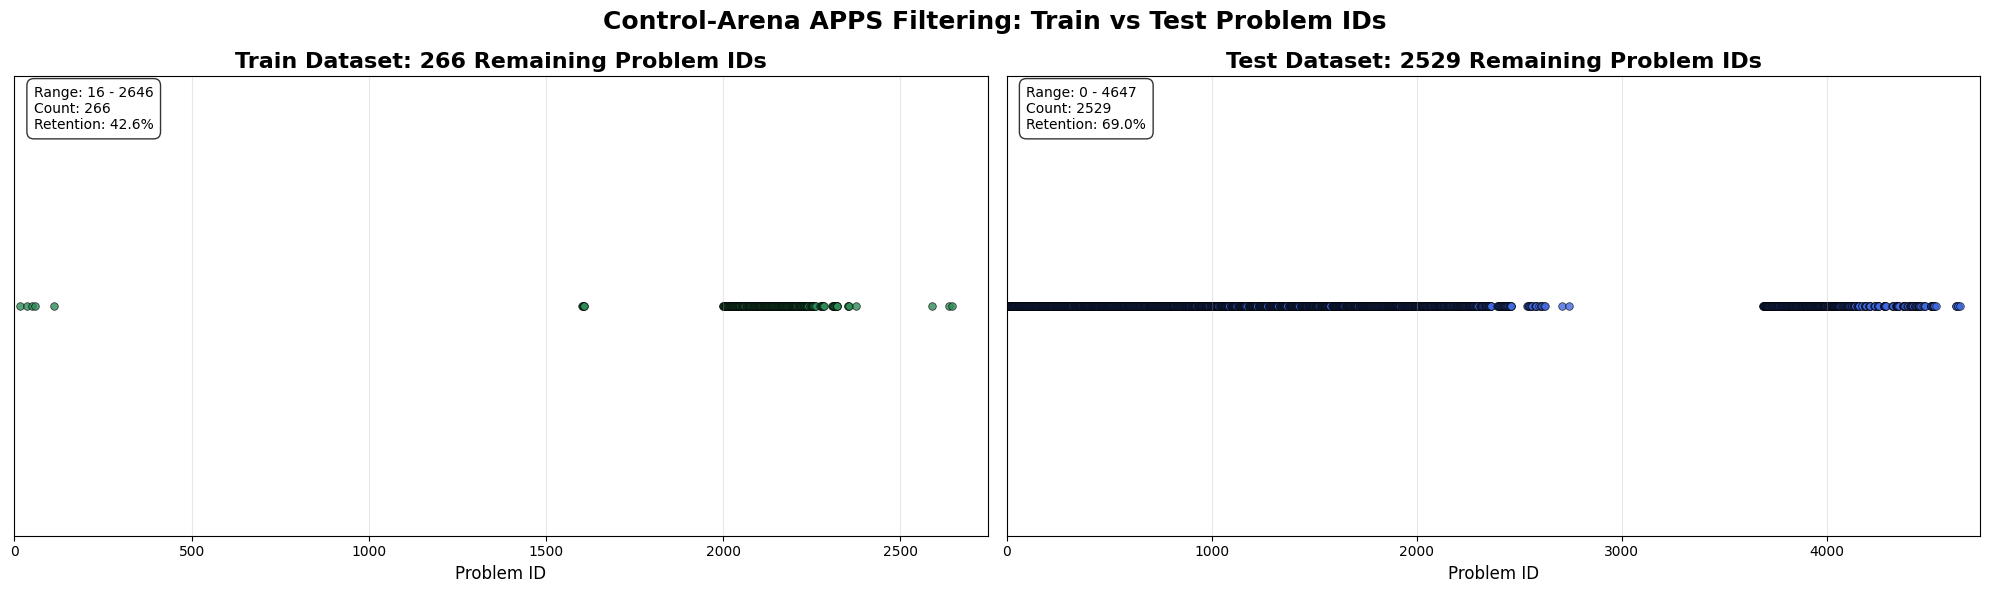


=== COMPLETE LISTS ===

All 266 Train Problem IDs:
[16, 36, 51, 58, 112, 1603, 1604, 1605, 1606, 1607, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2063, 2065, 2066, 2067, 2068, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2080, 2081, 2082, 2083, 2084, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102, 2103, 2104, 2105, 2106, 2107, 2108, 2110, 2111, 2112, 2113, 2114, 2115, 2116, 2117, 2118, 2119, 2120, 2121, 2122, 2123, 2124, 2125, 2126, 2127, 2128, 2129, 2130, 2131, 2132, 2133, 2134, 2135, 2137, 2138, 2139, 2140, 2141, 2142, 2143, 2144, 2145, 2146, 2147, 2148, 2149, 2151, 2152, 2153, 2154, 2155, 2157, 2158, 2159, 2160, 2161, 21

In [24]:
# Create a side-by-side comparison of train vs test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Train scatter plot
ax1.scatter(train_problem_ids_int, [1] * len(train_problem_ids_int), 
           c='#2E8B57', s=30, alpha=0.8, edgecolors='black', linewidth=0.5)
ax1.set_title(f'Train Dataset: {len(train_problem_ids_int)} Remaining Problem IDs', 
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Problem ID', fontsize=12)
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(train_problem_ids_int) + 100)

# Add statistics text
ax1.text(0.02, 0.98, f'Range: {min(train_problem_ids_int)} - {max(train_problem_ids_int)}\n'
                     f'Count: {len(train_problem_ids_int)}\n'
                     f'Retention: 42.6%', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# Test scatter plot
ax2.scatter(test_problem_ids_int, [1] * len(test_problem_ids_int), 
           c='#4169E1', s=30, alpha=0.8, edgecolors='black', linewidth=0.5)
ax2.set_title(f'Test Dataset: {len(test_problem_ids_int)} Remaining Problem IDs', 
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Problem ID', fontsize=12)
ax2.set_ylabel('')
ax2.set_yticks([])
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(test_problem_ids_int) + 100)

# Add statistics text
ax2.text(0.02, 0.98, f'Range: {min(test_problem_ids_int)} - {max(test_problem_ids_int)}\n'
                     f'Count: {len(test_problem_ids_int)}\n'
                     f'Retention: 69.0%', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.suptitle('Control-Arena APPS Filtering: Train vs Test Problem IDs', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Show the complete lists of problem IDs
print(f"\n=== COMPLETE LISTS ===")
print(f"\nAll {len(train_problem_ids_int)} Train Problem IDs:")
print(train_problem_ids_int)

print(f"\nAll {len(test_problem_ids_int)} Test Problem IDs:")
print(test_problem_ids_int)


In [25]:
# Analyze the test dataset filtering pattern
print("=== TEST DATASET FILTERING ANALYSIS ===")

# Get the original test problem IDs and the filtered ones
original_test_sorted = sorted(original_test_ids)
filtered_test_sorted = sorted(test_problem_ids_int)

print(f"Original test dataset: {len(original_test_sorted)} problems")
print(f"Filtered test dataset: {len(filtered_test_sorted)} problems")
print(f"Original range: {min(original_test_sorted)} to {max(original_test_sorted)}")
print(f"Filtered range: {min(filtered_test_sorted)} to {max(filtered_test_sorted)}")

# Find the first problem ID that gets filtered out
original_test_set = set(original_test_sorted)
filtered_test_set = set(filtered_test_sorted)
filtered_out_test = original_test_set - filtered_test_set
filtered_out_test_sorted = sorted(list(filtered_out_test))

print(f"\nFirst 20 problem IDs that get filtered out: {filtered_out_test_sorted[:20]}")
print(f"Last 20 problem IDs that get filtered out: {filtered_out_test_sorted[-20:]}")

# Check if the first half of test is mostly intact
first_half_cutoff = len(original_test_sorted) // 2
first_half_original = original_test_sorted[:first_half_cutoff]
first_half_filtered = [pid for pid in first_half_original if pid in filtered_test_set]

print(f"\nFirst half analysis (first {first_half_cutoff} problems):")
print(f"Original first half range: {min(first_half_original)} to {max(first_half_original)}")
print(f"Remaining in first half: {len(first_half_filtered)} out of {len(first_half_original)}")
print(f"First half retention rate: {len(first_half_filtered)/len(first_half_original)*100:.1f}%")

# Check the first 100, 200, 500 problems
for n in [100, 200, 500, 1000]:
    if n <= len(original_test_sorted):
        first_n_original = original_test_sorted[:n]
        first_n_filtered = [pid for pid in first_n_original if pid in filtered_test_set]
        retention_rate = len(first_n_filtered) / len(first_n_original) * 100
        print(f"First {n} problems: {len(first_n_filtered)}/{len(first_n_original)} remain ({retention_rate:.1f}%)")


=== TEST DATASET FILTERING ANALYSIS ===
Original test dataset: 3666 problems
Filtered test dataset: 2529 problems
Original range: 0 to 4750
Filtered range: 0 to 4647

First 20 problem IDs that get filtered out: [6, 19, 51, 69, 91, 105, 106, 117, 147, 159, 160, 190, 230, 232, 235, 257, 264, 270, 280, 287]
Last 20 problem IDs that get filtered out: [4706, 4707, 4708, 4709, 4710, 4711, 4712, 4713, 4714, 4715, 4716, 4717, 4718, 4719, 4720, 4721, 4722, 4723, 4724, 4750]

First half analysis (first 1833 problems):
Original first half range: 0 to 1832
Remaining in first half: 1600 out of 1833
First half retention rate: 87.3%
First 100 problems: 95/100 remain (95.0%)
First 200 problems: 188/200 remain (94.0%)
First 500 problems: 467/500 remain (93.4%)
First 1000 problems: 902/1000 remain (90.2%)


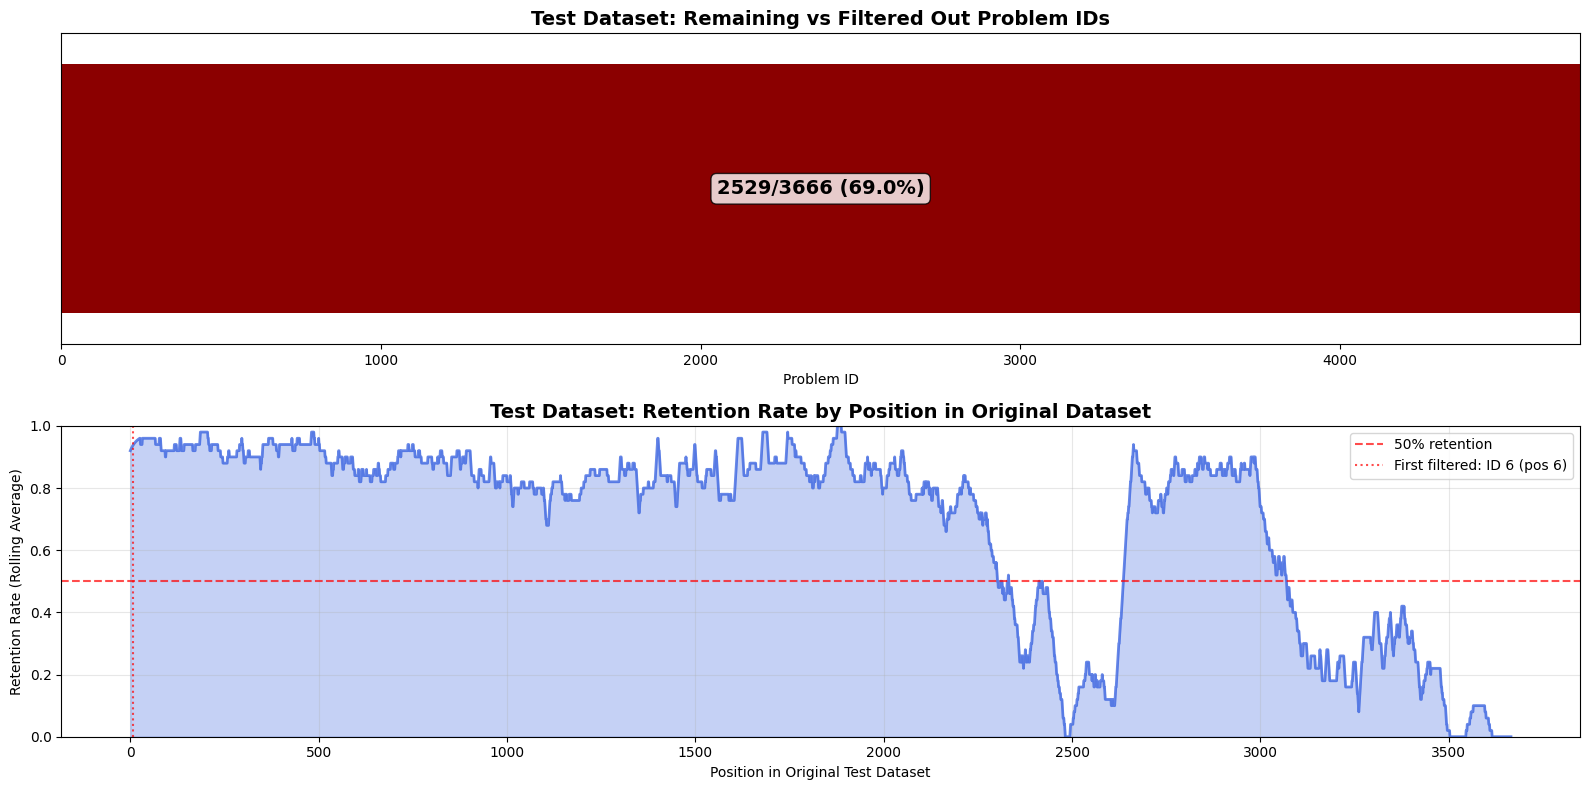


First problem ID that gets filtered out: 6
Position of first filtered problem in original dataset: 6


In [26]:
# Create a visualization showing the filtering pattern in the test dataset
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# Top plot: Show which problems remain vs are filtered out
all_test_ids = sorted(original_test_sorted + filtered_out_test_sorted)
remaining_mask = np.zeros(max(all_test_ids) + 1, dtype=bool)
for pid in filtered_test_sorted:
    if pid <= max(all_test_ids):
        remaining_mask[pid] = True

colors = ['#2E8B57' if remaining_mask[i] else '#8B0000' for i in range(max(all_test_ids) + 1)]
ax1.barh(0, range(max(all_test_ids) + 1), height=0.8, color=colors, linewidth=0)

ax1.set_xlim(0, max(all_test_ids))
ax1.set_ylim(-0.5, 0.5)
ax1.set_title('Test Dataset: Remaining vs Filtered Out Problem IDs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Problem ID')
ax1.set_yticks([])

# Add statistics
total_remaining = len(filtered_test_sorted)
total_original = len(original_test_sorted)
percentage = (total_remaining / total_original) * 100
ax1.text(max(all_test_ids) // 2, 0, f'{total_remaining}/{total_original} ({percentage:.1f}%)', 
         ha='center', va='center', fontsize=14, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Bottom plot: Show retention rate by position in the original dataset
positions = list(range(len(original_test_sorted)))
retention_by_position = [1 if pid in filtered_test_set else 0 for pid in original_test_sorted]

# Create a rolling average to smooth the data
window_size = 50
rolling_retention = []
for i in range(len(retention_by_position)):
    start = max(0, i - window_size // 2)
    end = min(len(retention_by_position), i + window_size // 2)
    rolling_retention.append(sum(retention_by_position[start:end]) / (end - start))

ax2.plot(positions, rolling_retention, color='#4169E1', linewidth=2, alpha=0.8)
ax2.fill_between(positions, rolling_retention, alpha=0.3, color='#4169E1')
ax2.set_title('Test Dataset: Retention Rate by Position in Original Dataset', fontsize=14, fontweight='bold')
ax2.set_xlabel('Position in Original Test Dataset')
ax2.set_ylabel('Retention Rate (Rolling Average)')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% retention')
ax2.legend()

# Add some key markers
first_filtered_out = filtered_out_test_sorted[0] if filtered_out_test_sorted else None
if first_filtered_out:
    first_filtered_position = original_test_sorted.index(first_filtered_out)
    ax2.axvline(x=first_filtered_position, color='red', linestyle=':', alpha=0.7, 
                label=f'First filtered: ID {first_filtered_out} (pos {first_filtered_position})')
    ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nFirst problem ID that gets filtered out: {filtered_out_test_sorted[0] if filtered_out_test_sorted else 'None'}")
print(f"Position of first filtered problem in original dataset: {original_test_sorted.index(filtered_out_test_sorted[0]) if filtered_out_test_sorted else 'N/A'}")


In [27]:
filtered_out_test_sorted

[6,
 19,
 51,
 69,
 91,
 105,
 106,
 117,
 147,
 159,
 160,
 190,
 230,
 232,
 235,
 257,
 264,
 270,
 280,
 287,
 321,
 323,
 325,
 326,
 341,
 369,
 370,
 403,
 412,
 417,
 454,
 455,
 474,
 512,
 514,
 525,
 527,
 541,
 544,
 558,
 559,
 579,
 587,
 588,
 601,
 608,
 615,
 616,
 620,
 631,
 632,
 643,
 652,
 658,
 661,
 665,
 677,
 684,
 686,
 689,
 693,
 711,
 723,
 739,
 742,
 764,
 776,
 780,
 790,
 793,
 797,
 825,
 826,
 827,
 841,
 852,
 856,
 865,
 866,
 898,
 899,
 900,
 912,
 927,
 928,
 929,
 930,
 937,
 947,
 956,
 962,
 963,
 982,
 987,
 990,
 991,
 992,
 993,
 1005,
 1012,
 1024,
 1034,
 1035,
 1036,
 1037,
 1038,
 1039,
 1040,
 1053,
 1070,
 1074,
 1085,
 1086,
 1087,
 1088,
 1089,
 1090,
 1093,
 1096,
 1116,
 1122,
 1123,
 1124,
 1125,
 1126,
 1127,
 1129,
 1139,
 1167,
 1170,
 1171,
 1172,
 1173,
 1174,
 1175,
 1176,
 1177,
 1178,
 1183,
 1195,
 1220,
 1222,
 1223,
 1224,
 1225,
 1226,
 1227,
 1258,
 1272,
 1273,
 1274,
 1275,
 1276,
 1277,
 1290,
 1294,
 1308,
 1326